# 🤖 Notebook 3: Model Training & Evaluation

## Learning Objectives
By the end of this notebook, you will:
- Train a Random Forest classifier
- Understand train/test splits for time series
- Evaluate model performance
- Interpret confusion matrices
- Understand feature importance
- Detect overfitting

## What You'll Learn
- How Random Forest works
- Evaluation metrics (accuracy, precision, recall)
- The importance of proper validation
- How to tune hyperparameters

---

## What is Random Forest?

Random Forest is an **ensemble learning** method:

1. **Create many decision trees** (e.g., 100 trees)
2. **Each tree trains on random subset** of data and features
3. **Each tree votes** on the prediction
4. **Majority vote wins**

### Why Random Forest?
- ✅ Handles non-linear relationships
- ✅ Resistant to overfitting (ensemble averages out noise)
- ✅ Provides feature importance scores
- ✅ Works well "out of the box" with minimal tuning

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

import sys
sys.path.append('..')
import config
from src.data_collection import load_stock_data
from src.preprocessing import preprocess_stock_data
from src.feature_engineering import engineer_all_features, prepare_ml_data
from src.models import split_train_test, train_random_forest, evaluate_model

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Ready to train models!")

✅ Imported necessary libraries
✅ Imported config settings
✅ Ready to train models!


## Step 1: Load Prepared Data

We'll use the features we created in Notebook 2.

In [2]:
# Load feature data
ticker = 'AAPL'
feature_path = config.get_data_path(ticker, 'features')

try:
    data = pd.read_csv(feature_path)
    data['Date'] = pd.to_datetime(data['Date'])
    print(f"✅ Loaded feature data: {data.shape}")
except FileNotFoundError:
    print("❌ Feature data not found. Running feature engineering...")
    raw_data = load_stock_data(ticker, 'raw')
    processed = preprocess_stock_data(raw_data)
    data = engineer_all_features(processed)
    print(f"✅ Created features: {data.shape}")

# Prepare X and y
X, y, feature_names = prepare_ml_data(data)

print(f"\n📊 Dataset ready:")
print(f"Samples: {len(X)}")
print(f"Features: {len(feature_names)}")
print(f"Target classes: {y.unique()}")

✅ Loaded feature data: (251, 19)
Dropped 21 rows with NaN values
Usable data: 230 rows

Features (15): ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'SMA_5', 'SMA_10', 'SMA_20', 'Volatility', 'Momentum', 'Volume_Change', 'HL_Spread', 'Sentiment_Proxy', 'Sentiment_SMA']
X shape: (230, 15)
y shape: (230,)

Target distribution:
Target
1    125
0    105
Name: count, dtype: int64
Percentage Up: 54.3%

📊 Dataset ready:
Samples: 230
Features: 15
Target classes: [1 0]


## Step 2: Train/Test Split

### CRITICAL: Time Series Split!

❌ **WRONG**: Random shuffle (leaks future info into training)
✅ **RIGHT**: Chronological split (train on past, test on future)

```
Data:     |-------------------|--------|
          |   Training Set    | Test   |
          |     (80%)         | (20%)  |
Time:     Past -----------> Present -> Future
```

In [3]:
# Split data
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2)

print("\n📊 Data Split:")
print(f"Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTraining period: rows {X_train.index[0]} to {X_train.index[-1]}")
print(f"Testing period:  rows {X_test.index[0]} to {X_test.index[-1]}")

# Check target distribution
print("\nTarget distribution:")
print(f"Training set: {y_train.value_counts().to_dict()}")
print(f"Testing set:  {y_test.value_counts().to_dict()}")

Train set: 184 samples
Test set: 46 samples
Train period: index 20 to 203
Test period: index 204 to 249

📊 Data Split:
Training: 184 samples (80.0%)
Testing:  46 samples (20.0%)

Training period: rows 20 to 203
Testing period:  rows 204 to 249

Target distribution:
Training set: {1: 99, 0: 85}
Testing set:  {1: 26, 0: 20}


## Step 3: Train Random Forest Model

Now for the exciting part - training our first ML model!

In [4]:
# Train model
print("Training Random Forest...")
print(f"Parameters: {config.RF_PARAMS}")

model = train_random_forest(X_train, y_train)

print("\n✅ Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features used: {model.n_features_in_}")

Training Random Forest...
Parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}

Training model...
✅ Model training complete!

✅ Model trained successfully!
Number of trees: 100
Number of features used: 15


## Step 4: Make Predictions

In [5]:
# Predict on both training and test sets
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Show some predictions
print("Sample Predictions (Test Set):")
print("="*60)
sample_df = pd.DataFrame({
    'Actual': y_test.head(10).values,
    'Predicted': test_predictions[:10],
    'Correct': y_test.head(10).values == test_predictions[:10]
})
print(sample_df)

correct = (y_test.head(10).values == test_predictions[:10]).sum()
print(f"\nCorrect in sample: {correct}/10")

Sample Predictions (Test Set):
   Actual  Predicted  Correct
0       0          1    False
1       1          1     True
2       1          1     True
3       1          1     True
4       1          1     True
5       1          1     True
6       0          1    False
7       1          0    False
8       1          0    False
9       1          0    False

Correct in sample: 5/10


## Step 5: Evaluate Performance

### Understanding Metrics:

- **Accuracy**: Overall % correct
- **Precision**: Of predicted "up", how many were actually up?
- **Recall**: Of actual "up" days, how many did we catch?
- **F1 Score**: Harmonic mean of precision and recall

In [6]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("📊 MODEL PERFORMANCE")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Check for overfitting
gap = train_accuracy - test_accuracy
if gap > 0.1:
    print(f"\n⚠️ Warning: Large gap ({gap:.2%}) suggests overfitting!")
elif gap < 0.05:
    print(f"\n✅ Good generalization (gap: {gap:.2%})")
else:
    print(f"\n✓ Acceptable gap: {gap:.2%}")

# Detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, test_predictions, 
                          target_names=['Down (0)', 'Up (1)']))

📊 MODEL PERFORMANCE
Training Accuracy: 0.9891 (98.91%)
Testing Accuracy:  0.5652 (56.52%)

⚠️ Warning: Large gap (42.39%) suggests overfitting!

DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Down (0)       0.50      0.50      0.50        20
      Up (1)       0.62      0.62      0.62        26

    accuracy                           0.57        46
   macro avg       0.56      0.56      0.56        46
weighted avg       0.57      0.57      0.57        46



## Step 6: Confusion Matrix

A confusion matrix shows:
- **True Negatives (TN)**: Correctly predicted down
- **False Positives (FP)**: Predicted up, actually down
- **False Negatives (FN)**: Predicted down, actually up
- **True Positives (TP)**: Correctly predicted up

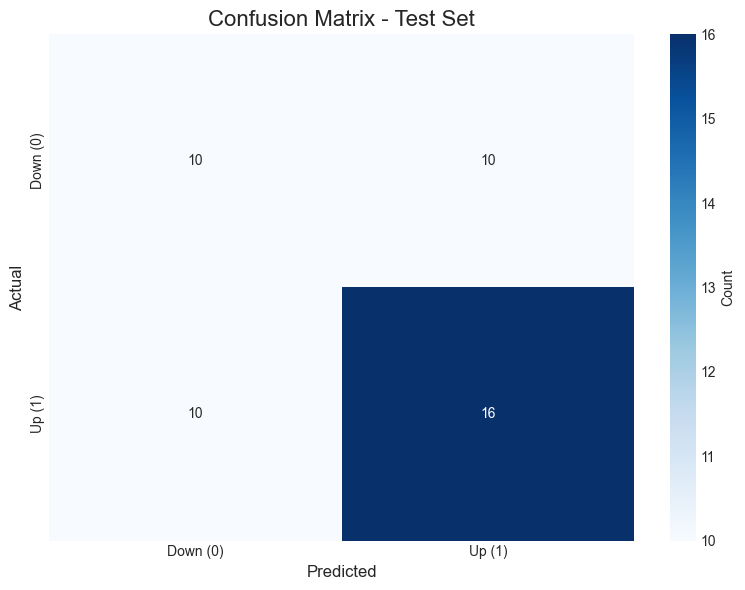


Confusion Matrix Breakdown:
True Negatives (predicted down, was down):    10
False Positives (predicted up, was down):     10
False Negatives (predicted down, was up):     10
True Positives (predicted up, was up):        16

Manual accuracy calc: (10 + 16) / 46 = 0.5652


In [7]:
# Create confusion matrix
cm = confusion_matrix(y_test, test_predictions)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)'],
            yticklabels=['Down (0)', 'Up (1)'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print("="*60)
print(f"True Negatives (predicted down, was down):  {tn:4d}")
print(f"False Positives (predicted up, was down):   {fp:4d}")
print(f"False Negatives (predicted down, was up):   {fn:4d}")
print(f"True Positives (predicted up, was up):      {tp:4d}")

# Accuracy calculation
manual_accuracy = (tn + tp) / (tn + fp + fn + tp)
print(f"\nManual accuracy calc: ({tn} + {tp}) / {tn + fp + fn + tp} = {manual_accuracy:.4f}")

## Step 7: Feature Importance

Which features does the model rely on most?

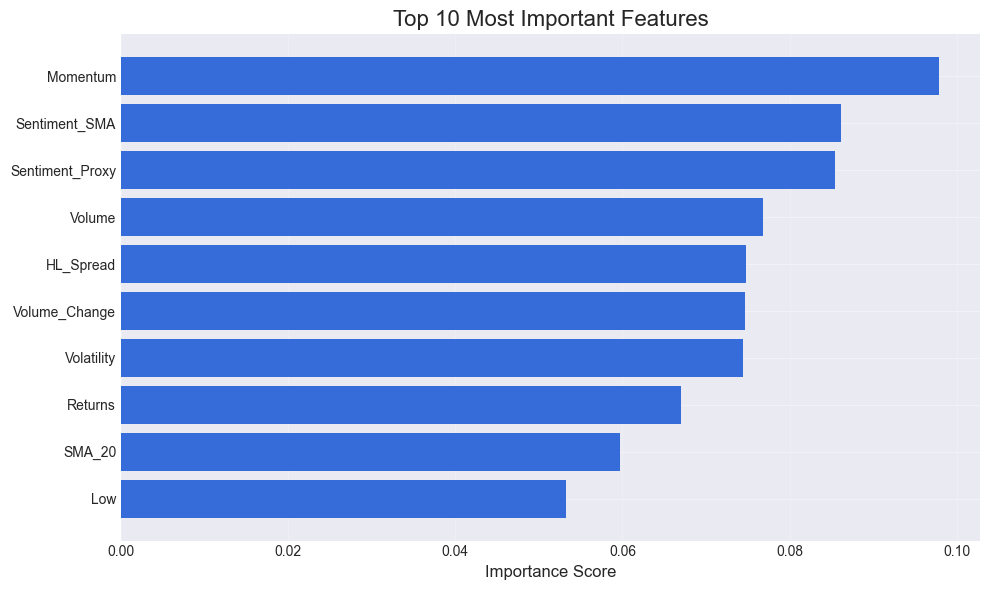


All Feature Importances:
Momentum            : 0.0979
Sentiment_SMA       : 0.0862
Sentiment_Proxy     : 0.0854
Volume              : 0.0768
HL_Spread           : 0.0747
Volume_Change       : 0.0746
Volatility          : 0.0745
Returns             : 0.0670
SMA_20              : 0.0597
Low                 : 0.0532
SMA_5               : 0.0531
Close               : 0.0517
High                : 0.0501
Open                : 0.0476
SMA_10              : 0.0474

💡 The model relies most on: Momentum


In [8]:
# Get feature importances
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
top_features = feature_imp_df.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 10 Most Important Features', fontsize=16)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print all importances
print("\nAll Feature Importances:")
print("="*60)
for _, row in feature_imp_df.iterrows():
    print(f"{row['Feature']:20s}: {row['Importance']:.4f}")

print(f"\n💡 The model relies most on: {feature_imp_df.iloc[0]['Feature']}")

## Step 8: Prediction Probability Analysis

Random Forest can also give us **probabilities** of each class.

Sample Predictions with Probabilities:
   Actual  Predicted  Prob_Down   Prob_Up
0       0          1   0.290317  0.709683
1       1          1   0.330862  0.669138
2       1          1   0.338442  0.661558
3       1          1   0.321067  0.678933
4       1          1   0.420314  0.579686
5       1          1   0.369606  0.630394
6       0          1   0.369833  0.630167
7       1          0   0.543833  0.456167
8       1          0   0.551333  0.448667
9       1          0   0.518317  0.481683


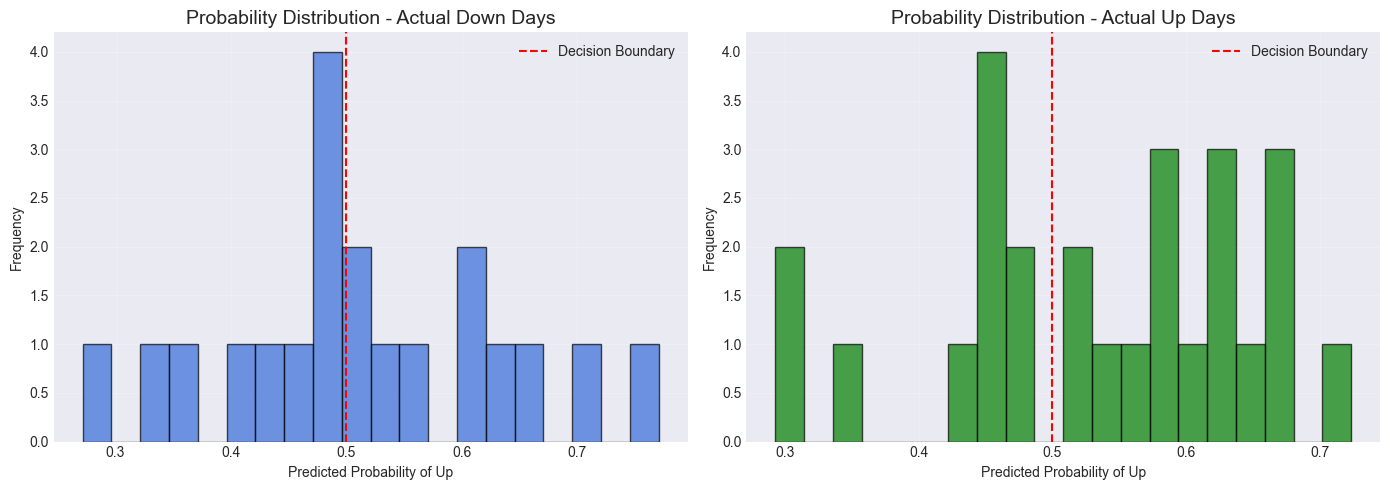


💡 Good separation means the model is confident in its predictions!


In [9]:
# Get prediction probabilities
test_proba = model.predict_proba(X_test)

# Probability of "up" (class 1)
prob_up = test_proba[:, 1]

# Create DataFrame
prob_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': test_predictions,
    'Prob_Down': test_proba[:, 0],
    'Prob_Up': test_proba[:, 1]
})

print("Sample Predictions with Probabilities:")
print(prob_df.head(10))

# Plot probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# When actual is down
axes[0].hist(prob_up[y_test == 0], bins=20, alpha=0.7, edgecolor='black')
axes[0].set_title('Probability Distribution - Actual Down Days', fontsize=14)
axes[0].set_xlabel('Predicted Probability of Up')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Decision Boundary')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# When actual is up
axes[1].hist(prob_up[y_test == 1], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Probability Distribution - Actual Up Days', fontsize=14)
axes[1].set_xlabel('Predicted Probability of Up')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Decision Boundary')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Good separation means the model is confident in its predictions!")

## Step 9: Compare with Baseline

How does our model compare to a simple baseline?

📊 BASELINE COMPARISON
Random Forest:        0.5652 (56.52%)
Majority Class:       0.5652 (56.52%)
Random Guessing:      0.5870 (58.70%)

✅ Our model beats majority baseline by: 0.0000 (0.00%)


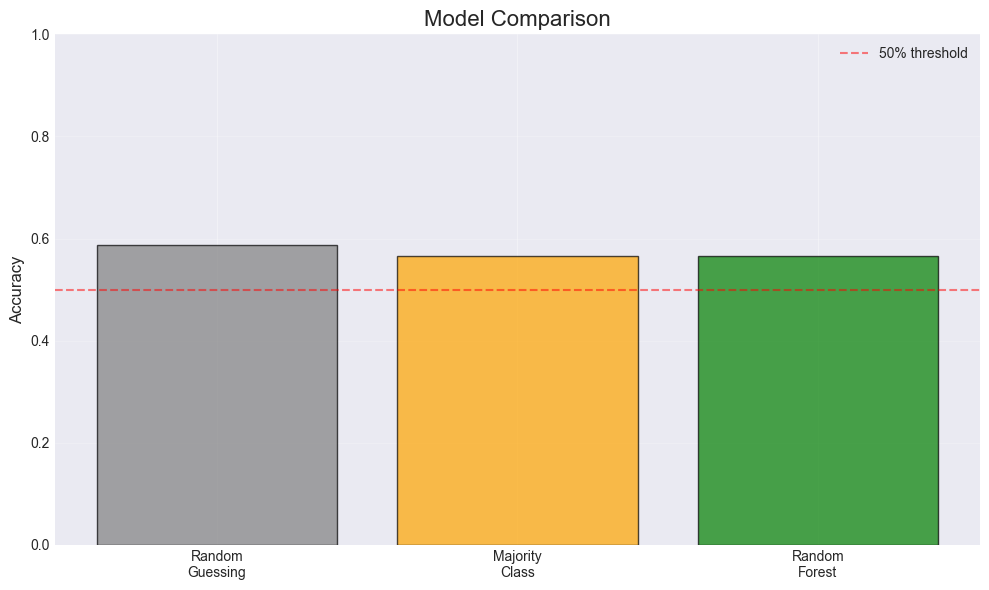

In [10]:
# Baseline 1: Always predict the majority class
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# Baseline 2: Random guessing (50/50)
random_pred = np.random.randint(0, 2, size=len(y_test))
random_accuracy = accuracy_score(y_test, random_pred)

print("📊 BASELINE COMPARISON")
print("="*60)
print(f"Random Forest:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Majority Class:       {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Random Guessing:      {random_accuracy:.4f} ({random_accuracy*100:.2f}%)")

improvement = test_accuracy - baseline_accuracy
print(f"\n✅ Our model beats majority baseline by: {improvement:.4f} ({improvement*100:.2f}%)")

# Visualize
models = ['Random\nGuessing', 'Majority\nClass', 'Random\nForest']
accuracies = [random_accuracy, baseline_accuracy, test_accuracy]
colors = ['gray', 'orange', 'green']

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison', fontsize=16)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 🎯 Exercise: Hyperparameter Tuning

Try different hyperparameter values and see how they affect performance!

In [11]:
# YOUR CODE HERE
# Experiment with different hyperparameters

# Try different values
n_estimators_list = [50, 100, 200]
max_depth_list = [5, 10, 15, None]

results = []

# Loop through combinations
for n_est in n_estimators_list:
    for max_d in max_depth_list:
        # Train model with these params
        params = {
            'n_estimators': n_est,
            'max_depth': max_d,
            'random_state': 42
        }
        
        # YOUR CODE: Train and evaluate
        # model = RandomForestClassifier(**params)
        # ...
        pass

# Find best combination
# Which hyperparameters gave the best test accuracy?

## 📝 Key Takeaways

1. **Random Forest** is an ensemble of decision trees
2. **Chronological split** is essential for time series
3. **Accuracy 60-70%** is actually good for stock prediction
4. **Confusion matrix** shows where the model makes mistakes
5. **Feature importance** reveals which variables matter most
6. **Overfitting** occurs when train >> test accuracy
7. Always **compare to baseline** to validate improvement

## Important Realizations

- 📊 **60% accuracy** means we're right 6 out of 10 times
- 💰 This is **better than random** and potentially profitable
- 📉 Stock markets are **inherently unpredictable**
- 🎯 The goal is to be **slightly better than chance**, consistently

## Next Steps

In Notebook 4, we'll validate our model properly using backtesting!

---

**Questions to think about:**
- Why can't we achieve 100% accuracy?
- What causes overfitting?
- Which evaluation metric matters most for trading?